<a href="https://colab.research.google.com/github/nbasaranakgul/Machine-Learning_AI/blob/main/Diabetes_Model_Improvement_T1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model Improvement Trial_1

## Data loading

Load  the sample dataset from the scikit library

The dataset is obtained from the NIH Data Resource.

In [ ]:
import pandas as pd
from sklearn.datasets import load_diabetes

# load the dataset
diabetes_data = load_diabetes()

In [ ]:
# Create DataFrame with features
diabetes_df = pd.DataFrame(diabetes_data.data, columns=diabetes_data.feature_names)

# Add the target variable as a column
diabetes_df['target'] = diabetes_data.target

# take a look at the dataframe
diabetes_df.head(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
5,-0.092695,-0.044642,-0.040696,-0.019442,-0.068991,-0.079288,0.041277,-0.076395,-0.041176,-0.096346,97.0
6,-0.045472,0.050680,-0.047163,-0.015999,-0.040096,-0.024800,0.000779,-0.039493,-0.062917,-0.038357,138.0
7,0.063504,0.050680,-0.001895,0.066629,0.090620,0.108914,0.022869,0.017703,-0.035816,0.003064,63.0
8,0.041708,0.050680,0.061696,-0.040099,-0.013953,0.006202,-0.028674,-0.002592,-0.014960,0.011349,110.0
9,-0.070900,-0.044642,0.039062,-0.033213,-0.012577,-0.034508,-0.024993,-0.002592,0.067737,-0.013504,310.0


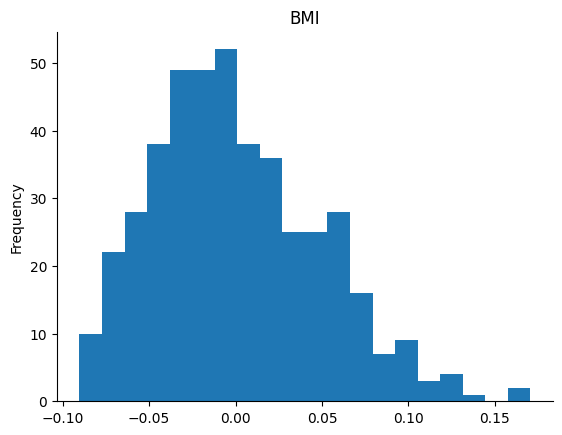

In [ ]:
# @title BMI

from matplotlib import pyplot as plt
diabetes_df['bmi'].plot(kind='hist', bins=20, title='BMI')
plt.gca().spines[['top', 'right']].set_visible(False)

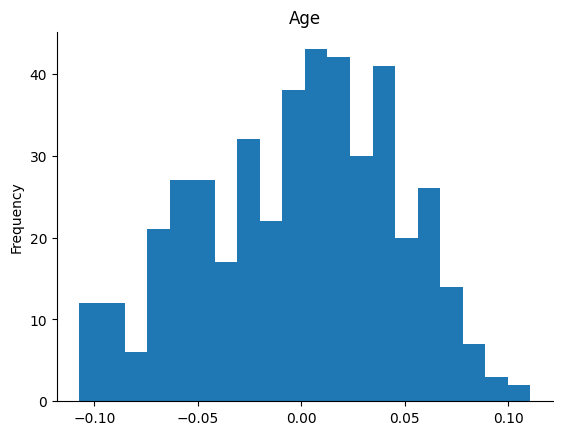

In [ ]:
# @title Age

from matplotlib import pyplot as plt
diabetes_df['age'].plot(kind='hist', bins=20, title='Age')
plt.gca().spines[['top', 'right',]].set_visible(False)

## Simple model fitting

Data is splitted to implement training and evaluating a linear regression model to see what model training looks like

In [ ]:
from sklearn.model_selection import train_test_split

# split the data into features and target
X = diabetes_df.drop(columns=['target'])
y = diabetes_df['target']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=20)

print(f"Shape of full dataset: {diabetes_df.shape}")
print(f"Shape of training data: features - {X_train.shape}, target - {y_train.shape}")
print(f"Shape of testing data: features - {X_test.shape}, target - {y_test.shape}")

Shape of full dataset: (442, 11)
Shape of training data: features - (353, 10), target - (353,)
Shape of testing data: features - (89, 10), target - (89,)


Split the data to train and evaluate our model.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# create an instance of the model and fit to the training data
model = LinearRegression()
model.fit(X_train, y_train)

# make predictions on both the training and test set
y_test_pred = model.predict(X_test)

# Calculate metrics for test set
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Print results
print("=== Model Performance ===")
print(f"Test R² Score: {test_r2:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

=== Model Performance ===
Test R² Score: 0.4180
Test RMSE: 58.8359


## Cross Validation

After completing the simple training, Cross validation is done to improve the one-time train-test split.

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_validate
import matplotlib.pyplot as plt

# define our linear regression pipeline
linear_regression_pipeline = make_pipeline(
    LinearRegression()
)

# define metrics
scoring = ['neg_mean_absolute_error', 'neg_root_mean_squared_error','r2']

# cross validate
cv_scores_lr = cross_validate(
        linear_regression_pipeline,
        X_train,
        y_train,
        cv=5,
        scoring=scoring,
        return_train_score=True
    )

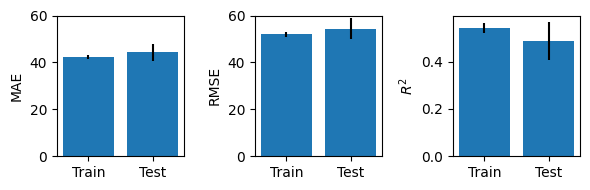

In [ ]:
# plot model evaluation results
plt.figure(figsize=(6,2))
plt.subplot(1,3,1)
plt.bar([0,1],
        [-np.mean(cv_scores_lr['train_neg_mean_absolute_error']),-np.mean(cv_scores_lr['test_neg_mean_absolute_error'])],
        yerr=[np.std(cv_scores_lr['train_neg_mean_absolute_error']),np.std(cv_scores_lr['test_neg_mean_absolute_error'])])
plt.xticks([0,1],['Train','Test'])
plt.ylabel('MAE')
plt.ylim([0,60])

plt.subplot(1,3,2)
plt.bar([0,1],
        [-np.mean(cv_scores_lr['train_neg_root_mean_squared_error']),-np.mean(cv_scores_lr['test_neg_root_mean_squared_error'])],
        yerr=[np.std(cv_scores_lr['train_neg_root_mean_squared_error']),np.std(cv_scores_lr['test_neg_root_mean_squared_error'])])
plt.xticks([0,1],['Train','Test'])
plt.ylabel('RMSE')
plt.ylim([0,60])

plt.subplot(1,3,3)
plt.bar([0,1],
        [np.mean(cv_scores_lr['train_r2']),np.mean(cv_scores_lr['test_r2'])],
        yerr=[np.std(cv_scores_lr['train_r2']),np.std(cv_scores_lr['test_r2'])])
plt.xticks([0,1],['Train','Test'])
plt.ylabel('$R^2$')

plt.tight_layout()
plt.show()

## Implementing other models

With a pipeline in place for linear regression, let's expand by looking at a few other model types:
- an ElasticNet regression
- a Random Forest Regressor
- a Gradient Boosting Model

In [ ]:
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# define pipelines
pipeline_en = make_pipeline(
    ElasticNet()
)

pipeline_rfr = make_pipeline(
    RandomForestRegressor()
)

pipeline_gbr = make_pipeline(
    GradientBoostingRegressor()
)

# perform cross-validation
cv_en = cross_validate(
        pipeline_en,
        X_train,
        y_train,
        cv=5,
        scoring=scoring,
        return_train_score=True
    )

cv_rfr = cross_validate(
        pipeline_rfr,
        X_train,
        y_train,
        cv=5,
        scoring=scoring,
        return_train_score=True
    )

cv_gbr = cross_validate(
        pipeline_gbr,
        X_train,
        y_train,
        cv=5,
        scoring=scoring,
        return_train_score=True
    )

print("Other three models trained!")

Other three models trained!


Looking into evaluation metrics for comparison.

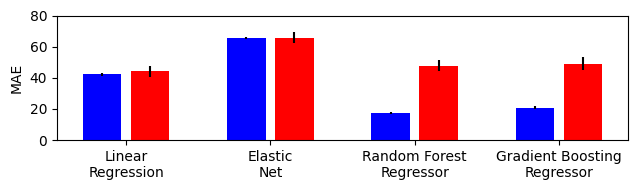

In [ ]:
# compare scores
plt.figure(figsize=(6.5,2))
plt.bar([0,1,3,4,6,7,9,10],
        [
            -np.mean(cv_scores_lr['train_neg_mean_absolute_error']),
            -np.mean(cv_scores_lr['test_neg_mean_absolute_error']),
            -np.mean(cv_en['train_neg_mean_absolute_error']),
            -np.mean(cv_en['test_neg_mean_absolute_error']),
            -np.mean(cv_rfr['train_neg_mean_absolute_error']),
            -np.mean(cv_rfr['test_neg_mean_absolute_error']),
            -np.mean(cv_gbr['train_neg_mean_absolute_error']),
            -np.mean(cv_gbr['test_neg_mean_absolute_error'])
        ],
        yerr=[
            np.std(cv_scores_lr['train_neg_mean_absolute_error']),
            np.std(cv_scores_lr['test_neg_mean_absolute_error']),
            np.std(cv_en['train_neg_mean_absolute_error']),
            np.std(cv_en['test_neg_mean_absolute_error']),
            np.std(cv_rfr['train_neg_mean_absolute_error']),
            np.std(cv_rfr['test_neg_mean_absolute_error']),
            np.std(cv_gbr['train_neg_mean_absolute_error']),
            np.std(cv_gbr['test_neg_mean_absolute_error'])
            ],
        color=['b','r'],
    )
plt.xticks([0.5,3.5,6.5,9.5],
           ['Linear\nRegression','Elastic\nNet','Random Forest\nRegressor','Gradient Boosting\nRegressor'])
plt.ylabel('MAE')
plt.ylim([0,80])
plt.tight_layout()
plt.show()

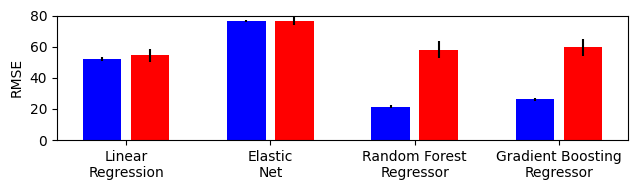

In [ ]:
plt.figure(figsize=(6.5,2))
plt.bar([0,1,3,4,6,7,9,10],
        [
            -np.mean(cv_scores_lr['train_neg_root_mean_squared_error']),
            -np.mean(cv_scores_lr['test_neg_root_mean_squared_error']),
            -np.mean(cv_en['train_neg_root_mean_squared_error']),
            -np.mean(cv_en['test_neg_root_mean_squared_error']),
            -np.mean(cv_rfr['train_neg_root_mean_squared_error']),
            -np.mean(cv_rfr['test_neg_root_mean_squared_error']),
            -np.mean(cv_gbr['train_neg_root_mean_squared_error']),
            -np.mean(cv_gbr['test_neg_root_mean_squared_error'])
        ],
        yerr=[
            np.std(cv_scores_lr['train_neg_root_mean_squared_error']),
            np.std(cv_scores_lr['test_neg_root_mean_squared_error']),
            np.std(cv_en['train_neg_root_mean_squared_error']),
            np.std(cv_en['test_neg_root_mean_squared_error']),
            np.std(cv_rfr['train_neg_root_mean_squared_error']),
            np.std(cv_rfr['test_neg_root_mean_squared_error']),
            np.std(cv_gbr['train_neg_root_mean_squared_error']),
            np.std(cv_gbr['test_neg_root_mean_squared_error'])
            ],
        color=['b','r'],
    )
plt.xticks([0.5,3.5,6.5,9.5],
           ['Linear\nRegression','Elastic\nNet','Random Forest\nRegressor','Gradient Boosting\nRegressor'])
plt.ylabel('RMSE')
plt.ylim([0,80])
plt.tight_layout()
plt.show()

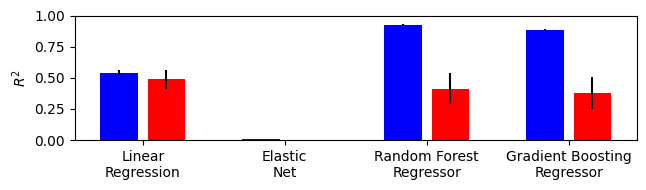

In [ ]:
plt.figure(figsize=(6.5,2))
plt.bar([0,1,3,4,6,7,9,10],
        [
            np.mean(cv_scores_lr['train_r2']),
            np.mean(cv_scores_lr['test_r2']),
            np.mean(cv_en['train_r2']),
            np.mean(cv_en['test_r2']),
            np.mean(cv_rfr['train_r2']),
            np.mean(cv_rfr['test_r2']),
            np.mean(cv_gbr['train_r2']),
            np.mean(cv_gbr['test_r2'])
        ],
        yerr=[
            np.std(cv_scores_lr['train_r2']),
            np.std(cv_scores_lr['test_r2']),
            np.std(cv_en['train_r2']),
            np.std(cv_en['test_r2']),
            np.std(cv_rfr['train_r2']),
            np.std(cv_rfr['test_r2']),
            np.std(cv_gbr['train_r2']),
            np.std(cv_gbr['test_r2'])
            ],
        color=['b','r'],
    )
plt.xticks([0.5,3.5,6.5,9.5],
           ['Linear\nRegression','Elastic\nNet','Random Forest\nRegressor','Gradient Boosting\nRegressor'])
plt.ylabel('$R^2$')
plt.ylim([0,1])
plt.tight_layout()
plt.show()

## Feature Selection

 Focused on the Random Forest Regressor and performed some feature selection because there are only a few models in play.

In [ ]:
from sklearn.feature_selection import SelectFromModel

pipeline_rfr_feat = make_pipeline(
    SelectFromModel(
        RandomForestRegressor(),
        threshold='median'  # Select features with importance above median
    ),
    RandomForestRegressor()
)

# Set custom step names
pipeline_rfr_feat.steps[0] = ('feature_selection', pipeline_rfr_feat.steps[0][1])
pipeline_rfr_feat.steps[1] = ('regressor', pipeline_rfr_feat.steps[1][1])

# Fit the pipeline to examine feature selection
pipeline_rfr_feat.fit(X_train, y_train)

# Extract the feature selector and final model
feature_selector = pipeline_rfr_feat.named_steps['feature_selection']
final_model = pipeline_rfr_feat.named_steps['regressor']

# Get feature importances from the selector's estimator
selector_rf = feature_selector.estimator_
feature_importances = selector_rf.feature_importances_
threshold_value = feature_selector.threshold_

# Create a comprehensive feature analysis
feature_analysis = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances,
    'Selected': feature_selector.get_support(),
    'Rank': np.argsort(feature_importances)[::-1] + 1
})

feature_analysis = feature_analysis.sort_values('Importance', ascending=False)

print("\n=== All Features Ranked by Importance ===")
for idx, row in feature_analysis.iterrows():
    status = "✓ SELECTED" if row['Selected'] else "✗ Removed"
    print(f"{row['Rank']:2d}. {row['Feature']:12} | Importance: {row['Importance']:.6f} | {status}")


=== All Features Ranked by Importance ===
 4. bmi          | Importance: 0.320120 | ✓ SELECTED
 8. s5           | Importance: 0.278079 | ✓ SELECTED
10. bp           | Importance: 0.100891 | ✓ SELECTED
 2. s6           | Importance: 0.059484 | ✓ SELECTED
 6. s3           | Importance: 0.055148 | ✓ SELECTED
 3. age          | Importance: 0.054757 | ✗ Removed
 1. s2           | Importance: 0.051737 | ✗ Removed
 7. s1           | Importance: 0.048761 | ✗ Removed
 5. s4           | Importance: 0.017947 | ✗ Removed
 9. sex          | Importance: 0.013076 | ✗ Removed


The model with feature selection is compared to the original.

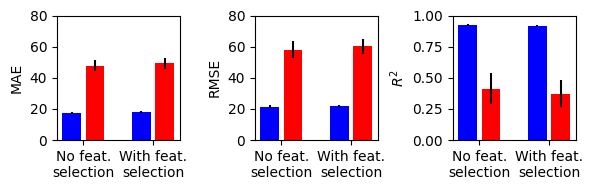

In [ ]:
cv_rfr_feat = cross_validate(
        pipeline_rfr_feat,
        X_train,
        y_train,
        cv=5,
        scoring=scoring,
        return_train_score=True
    )

plt.figure(figsize=(6,2))
plt.subplot(1,3,1)
plt.bar([0,1,3,4],
        [
            -np.mean(cv_rfr['train_neg_mean_absolute_error']),
            -np.mean(cv_rfr['test_neg_mean_absolute_error']),
            -np.mean(cv_rfr_feat['train_neg_mean_absolute_error']),
            -np.mean(cv_rfr_feat['test_neg_mean_absolute_error'])
        ],
        yerr=[
            np.std(cv_rfr['train_neg_mean_absolute_error']),
            np.std(cv_rfr['test_neg_mean_absolute_error']),
            np.std(cv_rfr_feat['train_neg_mean_absolute_error']),
            np.std(cv_rfr_feat['test_neg_mean_absolute_error'])
        ],
        color=['b','r'])
plt.xticks([.5,3.5],
           ['No feat.\nselection','With feat.\nselection'])
plt.ylim([0,80])
plt.ylabel('MAE')

plt.subplot(1,3,2)
plt.bar([0,1,3,4],
        [
            -np.mean(cv_rfr['train_neg_root_mean_squared_error']),
            -np.mean(cv_rfr['test_neg_root_mean_squared_error']),
            -np.mean(cv_rfr_feat['train_neg_root_mean_squared_error']),
            -np.mean(cv_rfr_feat['test_neg_root_mean_squared_error'])
        ],
        yerr=[
            np.std(cv_rfr['train_neg_root_mean_squared_error']),
            np.std(cv_rfr['test_neg_root_mean_squared_error']),
            np.std(cv_rfr_feat['train_neg_root_mean_squared_error']),
            np.std(cv_rfr_feat['test_neg_root_mean_squared_error'])
        ],
        color=['b','r'])
plt.xticks([.5,3.5],
           ['No feat.\nselection','With feat.\nselection'])
plt.ylim([0,80])
plt.ylabel('RMSE')

plt.subplot(1,3,3)
plt.bar([0,1,3,4],
        [
            np.mean(cv_rfr['train_r2']),
            np.mean(cv_rfr['test_r2']),
            np.mean(cv_rfr_feat['train_r2']),
            np.mean(cv_rfr_feat['test_r2'])
        ],
        yerr=[
            np.std(cv_rfr['train_r2']),
            np.std(cv_rfr['test_r2']),
            np.std(cv_rfr_feat['train_r2']),
            np.std(cv_rfr_feat['test_r2'])
        ],
        color=['b','r'])
plt.xticks([.5,3.5],
           ['No feat.\nselection','With feat.\nselection'])
plt.ylim([0,1])
plt.ylabel('$R^2$')

plt.tight_layout()
plt.show()

## Hyperparameter Tuning

 The hyperparameter tuning is implemented for the both feature selection and the model itself. Then, a randomized search is implemented to be able to fit many of the parameters.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer
from scipy.stats import randint

param_distributions = {
    # Feature selection parameters
    'feature_selection__estimator__n_estimators': randint(50, 200),
    'feature_selection__threshold': ['mean', 'median', '1.25*mean', '0.75*mean'],

    # Main regressor parameters
    'regressor__n_estimators': randint(100, 500),
    'regressor__max_depth': [None, 5, 10, 15, 20, 25, 30],
    'regressor__min_samples_split': randint(2, 20),
    'regressor__min_samples_leaf': randint(1, 10),
    'regressor__max_features': ['sqrt', 'log2', None, 0.5, 0.7],
    'regressor__bootstrap': [True, False]
}

# Custom scoring functions
def rmse_score(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

scoring = {
    'r2': 'r2',
    'neg_mse': 'neg_mean_squared_error',
    'rmse': make_scorer(rmse_score, greater_is_better=False)
}


print("\n🎲 Running Randomized Search...")
results = {}

# Randomized Search
random_search = RandomizedSearchCV(
    pipeline_rfr_feat,
    param_distributions,
    n_iter=100,  # Number of parameter combinations to try
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42,
    return_train_score=True
)

random_search.fit(X_train, y_train)

results['random'] = {
    'search': random_search,
    'best_score': random_search.best_score_,
    'best_params': random_search.best_params_
}

print(f"Best CV R² Score: {random_search.best_score_:.4f}")


🎲 Running Randomized Search...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best CV R² Score: 0.4566


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer
from scipy.stats import randint

param_distributions = {
    # Feature selection parameters
    'feature_selection__estimator__n_estimators': randint(50, 200),
    'feature_selection__threshold': ['mean', 'median', '1.25*mean', '0.75*mean'],

    # Main regressor parameters
    'regressor__n_estimators': randint(100, 500),
    'regressor__max_depth': [None, 5, 10, 15, 20, 25, 30],
    'regressor__min_samples_split': randint(2, 20),
    'regressor__min_samples_leaf': randint(1, 10),
    'regressor__max_features': ['sqrt', 'log2', None, 0.5, 0.7],
    'regressor__bootstrap': [True, False]
}

# Custom scoring functions
def rmse_score(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

scoring = {
    'r2': 'r2',
    'neg_mse': 'neg_mean_squared_error',
    'rmse': make_scorer(rmse_score, greater_is_better=False)
}


print("\n🎲 Running Randomized Search...")
results = {}

# Randomized Search
random_search = RandomizedSearchCV(
    pipeline_rfr_feat,
    param_distributions,
    n_iter=100,  # Number of parameter combinations to try
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42,
    return_train_score=True
)

random_search.fit(X_train, y_train)

results['random'] = {
    'search': random_search,
    'best_score': random_search.best_score_,
    'best_params': random_search.best_params_
}

print(f"Best CV R² Score: {random_search.best_score_:.4f}")


🎲 Running Randomized Search...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best CV R² Score: 0.4548
